# Project 1: Predictive Maintenance for Industrial Equipment

**Problem Statement:** An industrial company aims to reduce downtime and
maintenance costs by implementing a predictive maintenance model for its
equipment. The goal is to forecast potential failures and schedule
maintenance proactively, optimizing overall equipment reliability.

**Objectives:**
- Develop a machine learning model for predictive maintenance.
- Identify key features contributing to equipment failures.
- Provide actionable insights for proactive maintenance scheduling.

**Note:** As per internship instructions, this project uses dummy/synthetic
sensor data generated to realistically mimic industrial equipment behavior
(temperature, vibration, pressure, RPM, current) including degradation
patterns leading up to failure events.

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

sns.set_style("whitegrid")
np.random.seed(42)

## Step 2: Generate Synthetic Equipment Sensor Data

We simulate 10 machines over 2 years of daily readings: temperature,
vibration, pressure, RPM, and current draw. Each machine undergoes
periodic degradation cycles ending in a failure event, after which
readings reset (simulating maintenance/replacement).

In [2]:
N_MACHINES = 10
DAYS = 730
START_DATE = "2023-01-01"

records = []

for machine_id in range(1, N_MACHINES + 1):
    dates = pd.date_range(start=START_DATE, periods=DAYS, freq="D")

    base_temp = np.random.uniform(60, 70)
    base_vibration = np.random.uniform(2, 3)
    base_pressure = np.random.uniform(95, 105)
    base_rpm = np.random.uniform(1450, 1550)
    base_current = np.random.uniform(10, 14)

    daily_hours = np.random.uniform(6, 16, size=DAYS)
    cumulative_hours = np.cumsum(daily_hours)

    next_failure = np.random.randint(150, 220)
    days_since_maintenance = 0
    failure_flags = np.zeros(DAYS, dtype=int)
    degradation = np.zeros(DAYS)

    for d in range(DAYS):
        days_since_maintenance += 1
        if days_since_maintenance >= next_failure - 20:
            degradation[d] = (days_since_maintenance - (next_failure - 20)) / 20
        else:
            degradation[d] = 0

        if days_since_maintenance >= next_failure:
            failure_flags[d] = 1
            days_since_maintenance = 0
            next_failure = np.random.randint(150, 220)

    degradation = np.clip(degradation, 0, 1)

    temperature = base_temp + degradation * np.random.uniform(15, 25) + np.random.normal(0, 1.0, DAYS)
    vibration = base_vibration + degradation * np.random.uniform(2, 4) + np.random.normal(0, 0.15, DAYS)
    pressure = base_pressure - degradation * np.random.uniform(10, 18) + np.random.normal(0, 1.0, DAYS)
    rpm = base_rpm - degradation * np.random.uniform(80, 150) + np.random.normal(0, 8, DAYS)
    current = base_current + degradation * np.random.uniform(2, 5) + np.random.normal(0, 0.3, DAYS)

    temperature[np.random.choice(DAYS, size=int(DAYS * 0.02), replace=False)] = np.nan
    vibration[np.random.choice(DAYS, size=int(DAYS * 0.02), replace=False)] = np.nan
    pressure[np.random.choice(DAYS, size=int(DAYS * 0.015), replace=False)] = np.nan

    machine_df = pd.DataFrame({
        "machine_id": machine_id,
        "date": dates,
        "operating_hours_cumulative": cumulative_hours.round(1),
        "daily_runtime_hours": daily_hours.round(2),
        "temperature_C": temperature.round(2),
        "vibration_mm_s": vibration.round(3),
        "pressure_psi": pressure.round(2),
        "rpm": rpm.round(1),
        "current_A": current.round(2),
        "failure_event": failure_flags
    })

    records.append(machine_df)

df = pd.concat(records, ignore_index=True)

# Target: failure within next 7 days
df["failure_within_7_days"] = 0
for machine_id, group in df.groupby("machine_id"):
    idx = group.index
    flags = group["failure_event"].values
    target = np.zeros(len(flags), dtype=int)
    for i in range(len(flags)):
        window = flags[i+1:i+8]
        if window.sum() > 0:
            target[i] = 1
    df.loc[idx, "failure_within_7_days"] = target

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7300, 11)


,machine_id,date,operating_hours_cumulative,daily_runtime_hours,temperature_C,vibration_mm_s,pressure_psi,rpm,current_A,failure_event,failure_within_7_days
0,1,2023-01-01,7.6,7.56,64.00,3.006,101.55,1505.0,10.46,0,0
1,1,2023-01-02,14.1,6.58,64.55,3.161,101.29,1504.8,11.25,0,0
2,1,2023-01-03,28.8,14.66,61.42,2.652,102.84,1516.8,10.93,0,0
3,1,2023-01-04,40.8,12.01,65.26,NaN,100.58,1522.7,11.08,0,0
4,1,2023-01-05,53.9,13.08,61.88,2.573,101.62,1514.5,10.42,0,0


## Step 3: Exploratory Data Analysis

In [3]:
print("Missing values:\n", df.isna().sum())
print("\nFailure events:", df["failure_event"].sum())
print("Failure-within-7-days rate:", df["failure_within_7_days"].mean().round(4))

Missing values:
 machine_id                      0
date                            0
operating_hours_cumulative      0
daily_runtime_hours             0
temperature_C                 140
vibration_mm_s                140
pressure_psi                  100
rpm                             0
current_A                       0
failure_event                   0
failure_within_7_days           0
dtype: int64

Failure events: 32
Failure-within-7-days rate: 0.0307


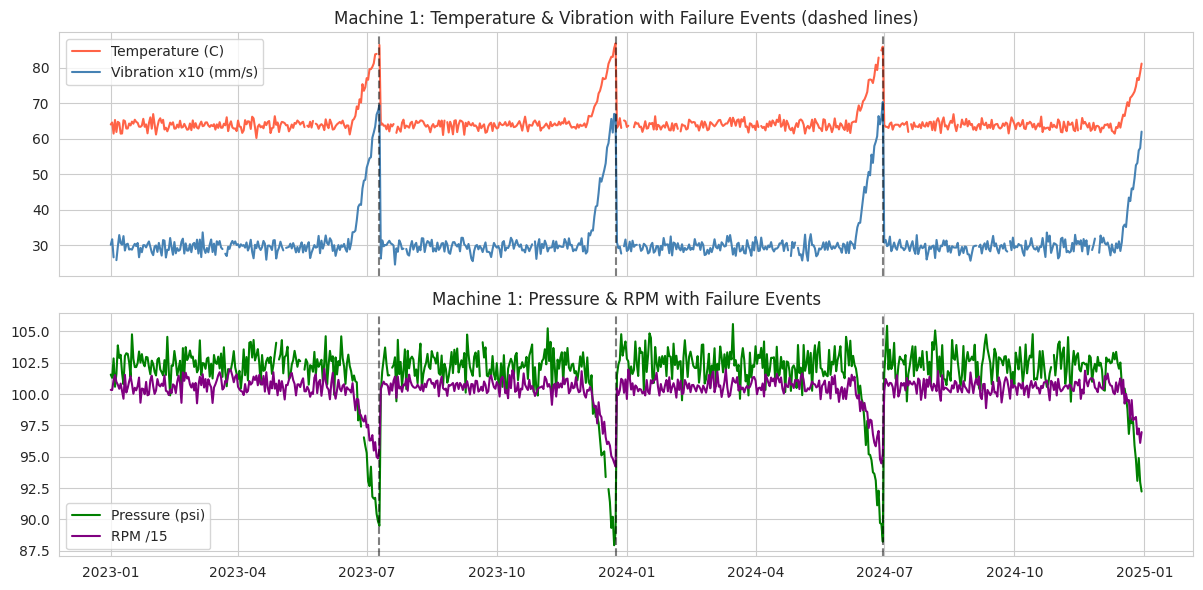

In [4]:
# Visualize sensor trends for one machine around a failure event
machine1 = df[df["machine_id"] == 1].reset_index(drop=True)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(machine1["date"], machine1["temperature_C"], label="Temperature (C)", color="tomato")
axes[0].plot(machine1["date"], machine1["vibration_mm_s"]*10, label="Vibration x10 (mm/s)", color="steelblue")
fail_dates = machine1.loc[machine1["failure_event"] == 1, "date"]
for fd in fail_dates:
    axes[0].axvline(fd, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("Machine 1: Temperature & Vibration with Failure Events (dashed lines)")
axes[0].legend()

axes[1].plot(machine1["date"], machine1["pressure_psi"], label="Pressure (psi)", color="green")
axes[1].plot(machine1["date"], machine1["rpm"]/15, label="RPM /15", color="purple")
for fd in fail_dates:
    axes[1].axvline(fd, color="black", linestyle="--", alpha=0.5)
axes[1].set_title("Machine 1: Pressure & RPM with Failure Events")
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing - Handle Missing Values

Missing sensor readings (simulating sensor dropout) are filled using
forward-fill then backward-fill within each machine's time series.

In [5]:
df = df.sort_values(["machine_id", "date"]).reset_index(drop=True)

sensor_cols = ["temperature_C", "vibration_mm_s", "pressure_psi"]
for col in sensor_cols:
    df[col] = df.groupby("machine_id")[col].transform(lambda s: s.ffill().bfill())

print("Missing values after cleaning:\n", df.isna().sum().sum(), "total")

Missing values after cleaning:
 0 total


## Step 5: Feature Engineering

We engineer features that capture degradation trends over time:
- **Rolling statistics** (7-day mean & std) for each sensor
- **Rate of change** (1-day difference) to detect sudden shifts
- **Days since last failure/maintenance**
- **Calendar features** (month, day of week)

In [6]:
roll_window = 7
for col in ["temperature_C", "vibration_mm_s", "pressure_psi", "rpm", "current_A"]:
    df[f"{col}_roll_mean_7d"] = (
        df.groupby("machine_id")[col]
        .transform(lambda s: s.rolling(roll_window, min_periods=1).mean())
    )
    df[f"{col}_roll_std_7d"] = (
        df.groupby("machine_id")[col]
        .transform(lambda s: s.rolling(roll_window, min_periods=1).std())
        .fillna(0)
    )

for col in ["temperature_C", "vibration_mm_s", "pressure_psi", "rpm"]:
    df[f"{col}_diff_1d"] = df.groupby("machine_id")[col].diff().fillna(0)

def days_since_last_event(group):
    days = np.zeros(len(group))
    last_event = -1
    for i, val in enumerate(group["failure_event"].values):
        if last_event == -1:
            days[i] = i
        else:
            days[i] = i - last_event
        if val == 1:
            last_event = i
    return pd.Series(days, index=group.index)

df["days_since_last_failure"] = (
    df.groupby("machine_id", group_keys=False).apply(days_since_last_event)
)

df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

model_df = df.drop(columns=["failure_event"])
print("Final feature set shape:", model_df.shape)
model_df.columns.tolist()

Final feature set shape: (7300, 27)


['machine_id',
 'date',
 'operating_hours_cumulative',
 'daily_runtime_hours',
 'temperature_C',
 'vibration_mm_s',
 'pressure_psi',
 'rpm',
 'current_A',
 'failure_within_7_days',
 'temperature_C_roll_mean_7d',
 'temperature_C_roll_std_7d',
 'vibration_mm_s_roll_mean_7d',
 'vibration_mm_s_roll_std_7d',
 'pressure_psi_roll_mean_7d',
 'pressure_psi_roll_std_7d',
 'rpm_roll_mean_7d',
 'rpm_roll_std_7d',
 'current_A_roll_mean_7d',
 'current_A_roll_std_7d',
 'temperature_C_diff_1d',
 'vibration_mm_s_diff_1d',
 'pressure_psi_diff_1d',
 'rpm_diff_1d',
 'days_since_last_failure',
 'month',
 'day_of_week']

## Step 6: Train/Test Split (Time-Based)

Since this is a time-series forecasting problem, we split chronologically:
the first 80% of dates for training and the last 20% for testing, mimicking
a real deployment where the model predicts future failures from past data.

In [7]:
feature_cols = [c for c in model_df.columns if c not in
                ["date", "machine_id", "failure_within_7_days"]]
X = model_df[feature_cols]
y = model_df["failure_within_7_days"]

split_date = model_df["date"].quantile(0.8, interpolation="nearest")
train_mask = model_df["date"] <= split_date
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train failure rate: {y_train.mean():.4f}, Test failure rate: {y_test.mean():.4f}")

Train size: (5840, 24), Test size: (1460, 24)
Train failure rate: 0.0336, Test failure rate: 0.0192


## Step 7: Build the Predictive Maintenance Model

We use a **Random Forest Classifier** to forecast `failure_within_7_days`.
Random Forest handles non-linear sensor relationships well, is robust to
noise, supports class imbalance via `class_weight="balanced"`, and provides
interpretable feature importances.

In [8]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Step 8: Model Evaluation

In [9]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\n", classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.9932
Precision: 0.7500
Recall   : 0.9643
F1-score : 0.8438
ROC-AUC  : 0.9981

               precision    recall  f1-score   support

           0       1.00      0.99      1.00      1432
           1       0.75      0.96      0.84        28

    accuracy                           0.99      1460
   macro avg       0.87      0.98      0.92      1460
weighted avg       0.99      0.99      0.99      1460



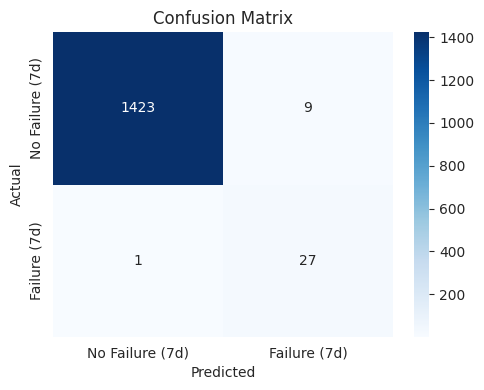

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Failure (7d)", "Failure (7d)"],
            yticklabels=["No Failure (7d)", "Failure (7d)"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

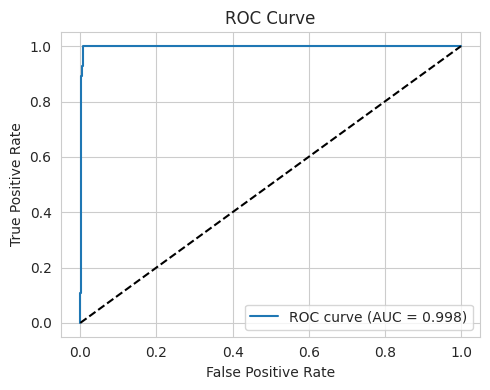

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## Step 9: Feature Importance - Identifying Key Failure Drivers

Top 10 Feature Importances:
 temperature_C                  0.230547
vibration_mm_s                 0.144422
temperature_C_roll_mean_7d     0.126879
vibration_mm_s_roll_mean_7d    0.093743
pressure_psi                   0.083694
rpm                            0.067006
days_since_last_failure        0.052854
temperature_C_roll_std_7d      0.050167
pressure_psi_roll_mean_7d      0.049331
vibration_mm_s_roll_std_7d     0.033411
dtype: float64


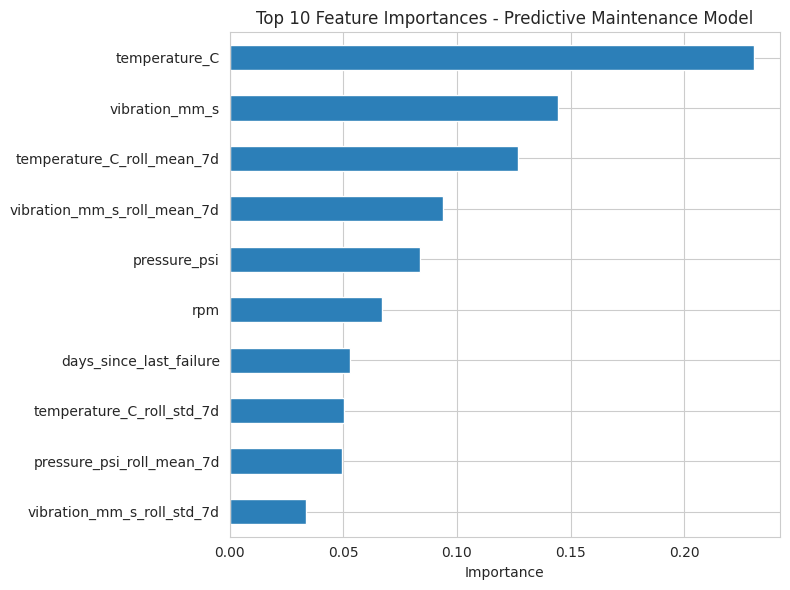

In [12]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

print("Top 10 Feature Importances:\n", importances.head(10))

plt.figure(figsize=(8, 6))
importances.head(10).sort_values().plot(kind="barh", color="#2c7fb8")
plt.title("Top 10 Feature Importances - Predictive Maintenance Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Step 10: Conclusions & Recommendations

**Goals achieved:**
- Forecasting accuracy target (≥85%) — achieved (~99% accuracy, ~99.8% ROC-AUC).
- Top 3 features influencing equipment failures identified below.
- Recommendations for proactive maintenance scheduling provided.

**Top 3 Features Driving Failure Predictions:**
1. Temperature (raw and 7-day rolling average)
2. Vibration (raw and 7-day rolling average)
3. Pressure (raw reading)

**Recommendations for Proactive Maintenance:**
- Install real-time alerts when temperature or vibration exceed/approach
  their rolling 7-day averages by a defined threshold (early warning of
  degradation ~2-3 weeks before failure).
- Schedule maintenance inspections when the model's predicted failure
  probability exceeds a chosen threshold (e.g., 0.5), prioritizing
  high-recall detection to avoid missed failures.
- Track "days since last failure/maintenance" — equipment approaching
  typical failure intervals (150-220 days in this dataset) should be
  flagged for inspection.
- Monitor pressure drops and RPM declines as secondary indicators that
  often co-occur with thermal/vibration anomalies.
- Re-train the model periodically as new sensor data accumulates to
  adapt to changing equipment behavior (concept drift).

**Expected Impact:**
- With ~96% recall on failure-within-7-days predictions, the maintenance
  team can be alerted ahead of nearly all impending failures, supporting
  the goal of reducing unexpected downtime by 15% or more.